In [1]:
import numpy as np
import pandas as pd

In [27]:
appliances = pd.read_json("../Data/Appliances.jsonl", lines=True)

In [28]:
appliances.drop(columns=['text', 'images', 'timestamp' ,'helpful_vote'], inplace=True)
appliances.rename(columns={'rating':'user_rating', 'title':'review', 'verified_purchased':'purchased'}, inplace=True)

In [29]:
appliances

,user_rating,review,asin,parent_asin,user_id,verified_purchase
0,5,Work great,B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True
1,5,excellent product,B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,True
2,5,Happy customer!,B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,True
3,5,Amazing value,B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,True
4,5,Dryer parts,B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,True
...,...,...,...,...,...,...
2128600,5,Accurate description,B097948QRP,B097948QRP,AG6IN4MOTWF3743PKIPHYA2S7GXA,True
2128601,3,Not compatible with Nespresso U Machine,B072QVZYDD,B0C6XG2JSG,AHVKX5FONDMQVOA7XLMPAH6EGZ2Q,True
2128602,5,Works with Sears Kenmore model 36275585891,B07QKBMPG2,B07QKBMPG2,AEYETSNK5VL6ZSLN32EE6VCOAYFA,True
2128603,5,Perfect little ice maker!,B07H7SGQ52,B07H7SGQ52,AHIJLNIXWVFQFWJV3OGGQOHONGMQ,True


In [34]:
meta_appliances = pd.read_json("../Data/meta_Appliances.jsonl", lines=True)

In [35]:
meta_appliances.drop(columns=['features', 'description', 'images', 'videos', 'store', 'categories', 'subtitle', 'author', 'bought_together'], inplace=True)
meta_appliances.rename(columns={'main_category':'category', 'title':'Product_Name'}, inplace=True)

In [36]:
meta_appliances

,category,Product_Name,average_rating,rating_number,price,details,parent_asin
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,NaN,"{'Brand': 'ROVSUN', 'Model Name': 'ICM-2005', ...",B08Z743RRD
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,NaN,"{'Manufacturer': 'HANSGO', 'Part Number': 'HAN...",B097BQDGHJ
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,NaN,"{'Manufacturer': 'RPI', 'Part Number': 'WE1M33...",B00IN9AGAE
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,NaN,"{'Manufacturer': 'folosem', 'Part Number': '15...",B0C7K98JZS
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,25.07,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B07QZHQTVJ
...,...,...,...,...,...,...,...
94322,Tools & Home Improvement,AMI PARTS,4.1,22,NaN,"{'Manufacturer': 'AMI PARTS', 'Part Number': '...",B07S5YQH3N
94323,Tools & Home Improvement,WP10442411 Refrigerator Defrost Thermostat Rep...,5.0,2,5.99,"{'Manufacturer': 'UpStart Components', 'Part N...",B082TY87VG
94324,Tools & Home Improvement,3957749 DRYER KNOB WHIRLPOOL ROPER USED PART fc,5.0,1,NaN,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B001EY0RIQ
94325,Tools & Home Improvement,5 Dryer Timer Knob Replacement for Frigidaire ...,5.0,1,NaN,"{'Manufacturer': 'UpStart Components', 'Part N...",B07JZFJYPK


In [41]:
print(meta_appliances.shape)
print(len(meta_appliances['parent_asin'].unique()))
print(len(meta_appliances['rating_number'].unique()))

(94327, 7)
94327
2453


In [48]:
meta_app = meta_appliances.drop(columns=['rating_number']).copy()

In [49]:
meta_app

,category,Product_Name,average_rating,price,details,parent_asin
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,NaN,"{'Brand': 'ROVSUN', 'Model Name': 'ICM-2005', ...",B08Z743RRD
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,NaN,"{'Manufacturer': 'HANSGO', 'Part Number': 'HAN...",B097BQDGHJ
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,NaN,"{'Manufacturer': 'RPI', 'Part Number': 'WE1M33...",B00IN9AGAE
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,NaN,"{'Manufacturer': 'folosem', 'Part Number': '15...",B0C7K98JZS
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,25.07,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B07QZHQTVJ
...,...,...,...,...,...,...
94322,Tools & Home Improvement,AMI PARTS,4.1,NaN,"{'Manufacturer': 'AMI PARTS', 'Part Number': '...",B07S5YQH3N
94323,Tools & Home Improvement,WP10442411 Refrigerator Defrost Thermostat Rep...,5.0,5.99,"{'Manufacturer': 'UpStart Components', 'Part N...",B082TY87VG
94324,Tools & Home Improvement,3957749 DRYER KNOB WHIRLPOOL ROPER USED PART fc,5.0,NaN,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B001EY0RIQ
94325,Tools & Home Improvement,5 Dryer Timer Knob Replacement for Frigidaire ...,5.0,NaN,"{'Manufacturer': 'UpStart Components', 'Part N...",B07JZFJYPK


In [50]:
app = appliances.copy()

In [51]:
app

,user_rating,review,asin,parent_asin,user_id,verified_purchase
0,5,Work great,B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True
1,5,excellent product,B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,True
2,5,Happy customer!,B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,True
3,5,Amazing value,B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,True
4,5,Dryer parts,B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,True
...,...,...,...,...,...,...
2128600,5,Accurate description,B097948QRP,B097948QRP,AG6IN4MOTWF3743PKIPHYA2S7GXA,True
2128601,3,Not compatible with Nespresso U Machine,B072QVZYDD,B0C6XG2JSG,AHVKX5FONDMQVOA7XLMPAH6EGZ2Q,True
2128602,5,Works with Sears Kenmore model 36275585891,B07QKBMPG2,B07QKBMPG2,AEYETSNK5VL6ZSLN32EE6VCOAYFA,True
2128603,5,Perfect little ice maker!,B07H7SGQ52,B07H7SGQ52,AHIJLNIXWVFQFWJV3OGGQOHONGMQ,True


In [53]:
len(app['asin'].unique())

104237

In [54]:
meta_app

,category,Product_Name,average_rating,price,details,parent_asin
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,NaN,"{'Brand': 'ROVSUN', 'Model Name': 'ICM-2005', ...",B08Z743RRD
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,NaN,"{'Manufacturer': 'HANSGO', 'Part Number': 'HAN...",B097BQDGHJ
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,NaN,"{'Manufacturer': 'RPI', 'Part Number': 'WE1M33...",B00IN9AGAE
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,NaN,"{'Manufacturer': 'folosem', 'Part Number': '15...",B0C7K98JZS
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,25.07,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B07QZHQTVJ
...,...,...,...,...,...,...
94322,Tools & Home Improvement,AMI PARTS,4.1,NaN,"{'Manufacturer': 'AMI PARTS', 'Part Number': '...",B07S5YQH3N
94323,Tools & Home Improvement,WP10442411 Refrigerator Defrost Thermostat Rep...,5.0,5.99,"{'Manufacturer': 'UpStart Components', 'Part N...",B082TY87VG
94324,Tools & Home Improvement,3957749 DRYER KNOB WHIRLPOOL ROPER USED PART fc,5.0,NaN,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B001EY0RIQ
94325,Tools & Home Improvement,5 Dryer Timer Knob Replacement for Frigidaire ...,5.0,NaN,"{'Manufacturer': 'UpStart Components', 'Part N...",B07JZFJYPK


<Axes: xlabel='category'>

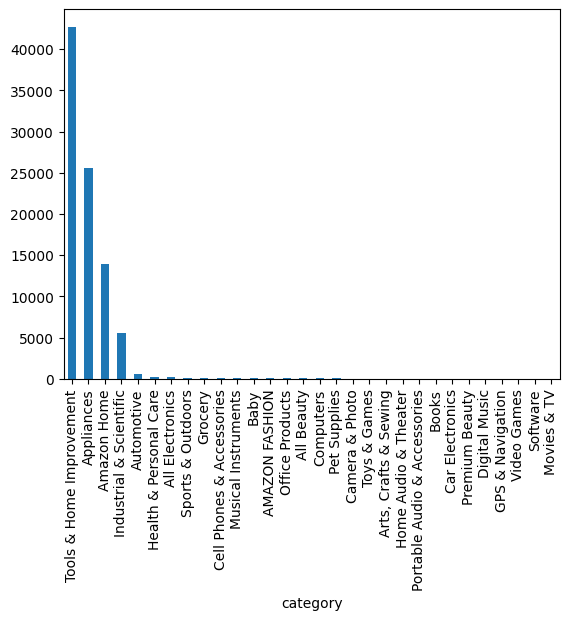

In [57]:
meta_app['category'].value_counts().plot(kind="bar")

In [60]:
meta_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94327 entries, 0 to 94326
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        89651 non-null  object 
 1   Product_Name    94327 non-null  object 
 2   average_rating  94327 non-null  float64
 3   price           46726 non-null  float64
 4   details         94327 non-null  object 
 5   parent_asin     94327 non-null  object 
dtypes: float64(2), object(4)
memory usage: 4.3+ MB


In [62]:
meta_app[meta_app['parent_asin'] == 'B08Z743RRD']

,category,Product_Name,average_rating,price,details,parent_asin
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,NaN,"{'Brand': 'ROVSUN', 'Model Name': 'ICM-2005', ...",B08Z743RRD


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='average_rating', ylabel='Count'>

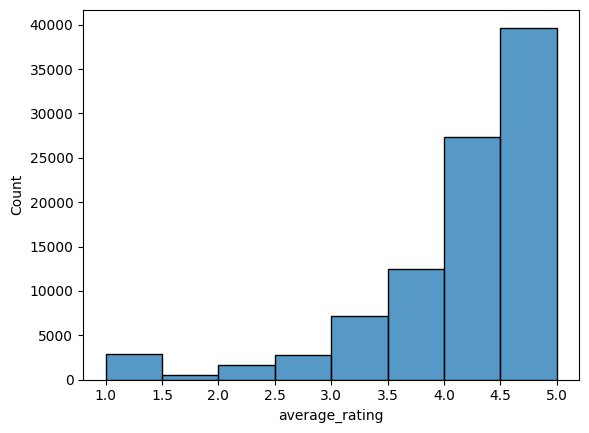

In [65]:
sns.histplot(meta_app['average_rating'], bins = 8)

In [66]:
app

,user_rating,review,asin,parent_asin,user_id,verified_purchase
0,5,Work great,B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True
1,5,excellent product,B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,True
2,5,Happy customer!,B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,True
3,5,Amazing value,B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,True
4,5,Dryer parts,B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,True
...,...,...,...,...,...,...
2128600,5,Accurate description,B097948QRP,B097948QRP,AG6IN4MOTWF3743PKIPHYA2S7GXA,True
2128601,3,Not compatible with Nespresso U Machine,B072QVZYDD,B0C6XG2JSG,AHVKX5FONDMQVOA7XLMPAH6EGZ2Q,True
2128602,5,Works with Sears Kenmore model 36275585891,B07QKBMPG2,B07QKBMPG2,AEYETSNK5VL6ZSLN32EE6VCOAYFA,True
2128603,5,Perfect little ice maker!,B07H7SGQ52,B07H7SGQ52,AHIJLNIXWVFQFWJV3OGGQOHONGMQ,True


In [71]:
print(f"The number of unique items bought by the customers are: {len(app['parent_asin'].unique())}")
print(f"The total number of unique items availabe are: {len(meta_app['parent_asin'].unique())}")

The number of unique items bought by the customers are: 94319
The total number of unique items availabe are: 94327


In [77]:
app.groupby(['parent_asin'])['asin'].count()

parent_asin
0967805929    138
1508810133      5
1563834103     16
1906487049      3
1926644743     66
             ... 
B0CK13445Y      2
B0CK1WTS8H      1
B0CK5B9JSX      2
B0CKK87VTT      1
B0CKR66M1V      2
Name: asin, Length: 94319, dtype: int64

In [83]:
app[app['parent_asin'] == "0967805929"]["review"].sample(50)

1883993    I purchased the book to get a clear understand...
1798699                        Variation Of A Same Old Theme
1883998    Not every "condition" or illness is covered in...
804917                             Informative and educating
1401534              Every church should offer this training
661952                                               Awesome
1884004                                           SNAKE OIL!
1026184                                          Great read!
1884015              Dr. Henry Wright...A More Excellent Way
950531                                          A Better Way
1505968                                           Five Stars
1883988                                          A must have
1884011                  Keys for those who Minister healing
314481                                    A Real Eye Opener!
19639                                   A More Excellent way
581941                                            Five Stars
1883989    Christians an

<Axes: xlabel='user_rating', ylabel='Count'>

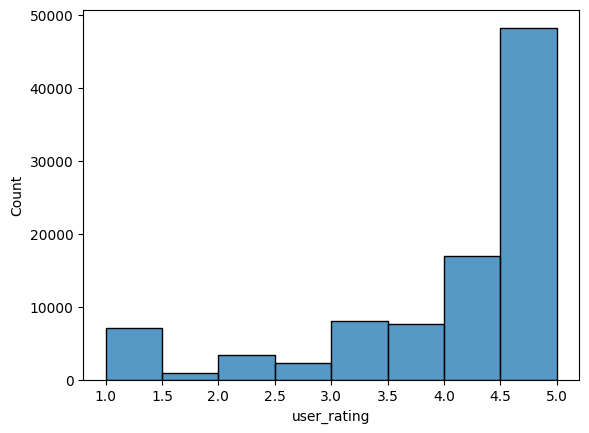

In [86]:
sns.histplot(app.groupby(['parent_asin'])['user_rating'].mean(), bins = 8)

<Axes: xlabel='average_rating', ylabel='Count'>

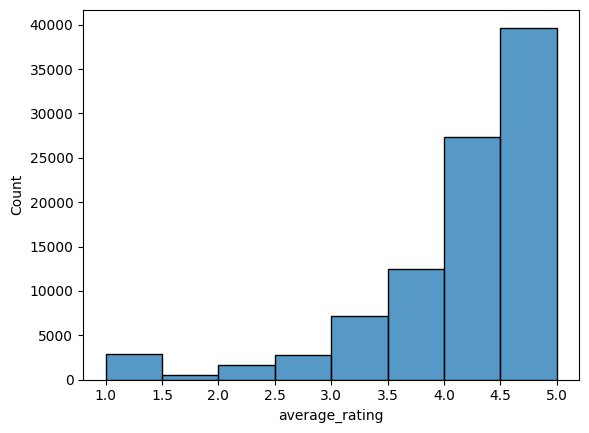

In [87]:
sns.histplot(meta_app['average_rating'], bins = 8)

In [88]:
meta_app

,category,Product_Name,average_rating,price,details,parent_asin
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,NaN,"{'Brand': 'ROVSUN', 'Model Name': 'ICM-2005', ...",B08Z743RRD
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,NaN,"{'Manufacturer': 'HANSGO', 'Part Number': 'HAN...",B097BQDGHJ
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,NaN,"{'Manufacturer': 'RPI', 'Part Number': 'WE1M33...",B00IN9AGAE
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,NaN,"{'Manufacturer': 'folosem', 'Part Number': '15...",B0C7K98JZS
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,25.07,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B07QZHQTVJ
...,...,...,...,...,...,...
94322,Tools & Home Improvement,AMI PARTS,4.1,NaN,"{'Manufacturer': 'AMI PARTS', 'Part Number': '...",B07S5YQH3N
94323,Tools & Home Improvement,WP10442411 Refrigerator Defrost Thermostat Rep...,5.0,5.99,"{'Manufacturer': 'UpStart Components', 'Part N...",B082TY87VG
94324,Tools & Home Improvement,3957749 DRYER KNOB WHIRLPOOL ROPER USED PART fc,5.0,NaN,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B001EY0RIQ
94325,Tools & Home Improvement,5 Dryer Timer Knob Replacement for Frigidaire ...,5.0,NaN,"{'Manufacturer': 'UpStart Components', 'Part N...",B07JZFJYPK


In [89]:
app

,user_rating,review,asin,parent_asin,user_id,verified_purchase
0,5,Work great,B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True
1,5,excellent product,B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,True
2,5,Happy customer!,B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,True
3,5,Amazing value,B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,True
4,5,Dryer parts,B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,True
...,...,...,...,...,...,...
2128600,5,Accurate description,B097948QRP,B097948QRP,AG6IN4MOTWF3743PKIPHYA2S7GXA,True
2128601,3,Not compatible with Nespresso U Machine,B072QVZYDD,B0C6XG2JSG,AHVKX5FONDMQVOA7XLMPAH6EGZ2Q,True
2128602,5,Works with Sears Kenmore model 36275585891,B07QKBMPG2,B07QKBMPG2,AEYETSNK5VL6ZSLN32EE6VCOAYFA,True
2128603,5,Perfect little ice maker!,B07H7SGQ52,B07H7SGQ52,AHIJLNIXWVFQFWJV3OGGQOHONGMQ,True


In [93]:
app[app['verified_purchase']==False]

,user_rating,review,asin,parent_asin,user_id,verified_purchase
59,5,Fits well.,B07KMYFCNH,B0C2Z4QHXG,AHACLF2COQQE2V33ZFXQ7THZOJ2Q,False
62,5,"Nice and compact, but will hold 30 eggs.",B09XHX6LNR,B0BG5J27Q7,AFAIJYOUO3NAWLBDIKTQSC3DASWA,False
66,3,Good,B09TZQ7CLG,B09TZQ7CLG,AFFZVSTUS3U2ZD22A2NPZSKOCPGQ,False
67,5,"and better yet, can stack other items on top o...",B076QPN519,B076QPN519,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,False
71,5,Worked!,B07LG8QYFW,B07LG8QYFW,AHATA6X6MYTC3VNBFJ3WIYVK257A,False
...,...,...,...,...,...,...
2128509,5,product was great,B0BB2R22PJ,B0BB2R22PJ,AHFOX2ONX5ZCIMVJFLPM56RAD2JA,False
2128511,5,So Far So Good,B0BB2R22PJ,B0BB2R22PJ,AGBWDMEAZPJZDG6MZD4R3BXVZVAA,False
2128527,1,Skip this Washer,B00CA9TTJ2,B00CA9TTJ2,AH24DN6ANFK2ZD32YM6AID2XAMPA,False
2128576,5,My Birthday gift from my son.,B0BTT2T9W9,B0C8JVGC91,AGKU7UU7JWA2JO2AXNVLGXXBXGPQ,False


In [96]:
meta_app.rename(columns={'category':'Category', 'average_rating':'Avg_Rating', 'price':'Price', 'details':'Details', 'parent_asin':'Parent_ASIN'}, inplace=True)
meta_app

,Category,Product_Name,Avg_Rating,Price,Details,Parent_ASIN
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,NaN,"{'Brand': 'ROVSUN', 'Model Name': 'ICM-2005', ...",B08Z743RRD
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,NaN,"{'Manufacturer': 'HANSGO', 'Part Number': 'HAN...",B097BQDGHJ
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,NaN,"{'Manufacturer': 'RPI', 'Part Number': 'WE1M33...",B00IN9AGAE
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,NaN,"{'Manufacturer': 'folosem', 'Part Number': '15...",B0C7K98JZS
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,25.07,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B07QZHQTVJ
...,...,...,...,...,...,...
94322,Tools & Home Improvement,AMI PARTS,4.1,NaN,"{'Manufacturer': 'AMI PARTS', 'Part Number': '...",B07S5YQH3N
94323,Tools & Home Improvement,WP10442411 Refrigerator Defrost Thermostat Rep...,5.0,5.99,"{'Manufacturer': 'UpStart Components', 'Part N...",B082TY87VG
94324,Tools & Home Improvement,3957749 DRYER KNOB WHIRLPOOL ROPER USED PART fc,5.0,NaN,"{'Manufacturer': 'Whirlpool', 'Part Number': '...",B001EY0RIQ
94325,Tools & Home Improvement,5 Dryer Timer Knob Replacement for Frigidaire ...,5.0,NaN,"{'Manufacturer': 'UpStart Components', 'Part N...",B07JZFJYPK


In [98]:
app.drop(columns=['asin'], inplace=True)

In [99]:
app

,user_rating,review,parent_asin,user_id,verified_purchase
0,5,Work great,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True
1,5,excellent product,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,True
2,5,Happy customer!,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,True
3,5,Amazing value,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,True
4,5,Dryer parts,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,True
...,...,...,...,...,...
2128600,5,Accurate description,B097948QRP,AG6IN4MOTWF3743PKIPHYA2S7GXA,True
2128601,3,Not compatible with Nespresso U Machine,B0C6XG2JSG,AHVKX5FONDMQVOA7XLMPAH6EGZ2Q,True
2128602,5,Works with Sears Kenmore model 36275585891,B07QKBMPG2,AEYETSNK5VL6ZSLN32EE6VCOAYFA,True
2128603,5,Perfect little ice maker!,B07H7SGQ52,AHIJLNIXWVFQFWJV3OGGQOHONGMQ,True


In [100]:
cleaned_meta_app = meta_app.copy()
cleaned_app = app.copy()

In [103]:
cleaned_meta_app.to_csv("../Data/cleaned_meta_app.csv", index=False)
cleaned_app.to_csv("../Data/cleaned_app.csv", index=False)